# BP3 — Gmsh 2D Fault Mesh

## Workflow

This notebook builds a 2D subduction-zone mesh for a bp3 Tandem simulation. The main idea is to create a rectangular/trapezoidal computational domain, split it into two material blocks by the dipping fault, and then attach **physical tags** that Tandem can use to apply boundary conditions.

The mesh is constructed in the following order:

1. **Parameters** — choose the target mesh resolution near the fault and trench, and set the fault dip.
2. **Geometry** — define the size of the computational box and the depth of the rate-and-state part of the fault.
3. **Points** — create the key vertices of the model: outer boundaries, trench, deep fault continuation, and RSF fault tip.
4. **Lines** — connect the points into outer-boundary segments and fault segments.
5. **Curve Loops & Surfaces** — close the line segments into two surfaces: downgoing plate and upper plate.
6. **Physical Groups** — label curves and surfaces with IDs that Tandem reads from the `.msh` file.
7. **Mesh Size Fields** — refine the mesh close to the RSF fault and near the trench, while allowing coarser elements far away.
8. **Generate & Export** — generate the 2D triangular mesh and write it as `bp3.msh`.



## Parameters

Here we define a number of parameters that will be used throughout the notebook.
Tandem works in **km**, so all geometric lengths below are in kilometers.

| Parameter | Default | Unit | Meaning |
|-----------|---------|------|-----------------------------------------|
| `Lf`      | 0.2     | km   | Target element size close to the RSF fault plane |
| `Ls`      | 0.2     | km   | Target element size close to the trench |
| `dip`     | 30°     | deg  | Fault dip angle measured downward from the horizontal |

`Lf` and `Ls` are not the element size everywhere. They are the **smallest desired sizes** near two important features:

- `Lf` controls refinement around the rate-and-state friction part of the fault, where slip and stress gradients are expected to be strongest.
- `Ls` controls refinement around the trench, where the geometry changes sharply and where the fault reaches the surface.

Away from these features, the mesh-size fields defined later let the elements grow gradually. This avoids using a very fine mesh throughout the whole 400 km deep domain.

In [3]:
import numpy as np

Lf  = 0.2    # km — base mesh size around the fault plane
Ls  = 0.2    # km — base mesh size near the trench
dip = 60.0   # degrees — fault dip angle

dip_rad = np.radians(dip)

## Geometry

Here we define the parameters that control the geometry of our domain.
The computational domain is built around a dipping fault that starts at the trench `(0, 0)` and dips down to the right. The vertical coordinate `y` is negative downward.

| Variable | Value | Unit | Meaning |
|----------|-------|------|-------------------------------------------------|
| `h`      | 40    | km   | Coarse target size at the far outer-boundary points |
| `d`      | 400   | km   | Domain depth, extending from `y = 0` to `y = -d` |
| `w`      | —     | km   | Horizontal half-width of the top boundary; computed from the dip and clamped so the model is at least as wide as it is deep |
| `max_depth_of_rsf_fault` | 70 | km | Down-dip depth of the rate-and-state fault segment |

`w = d * cos(dip) / sin(dip)` is the horizontal distance from the trench to where the fault reaches depth `d`. It is then clamped to `max(w, d)` so steep dips don't produce a domain that's too narrow relative to its depth.

In [4]:
h  = 40    # km — coarse target element size at outer boundary points
d  = 400   # km — domain depth
max_depth_of_rsf_fault = 40    # km — down-dip depth of the RSF segment

# Horizontal projection of a dipping line from the trench to depth d.
# This sets the model width large enough that the bottom fault continuation fits inside the domain.
w = d * np.cos(dip_rad) / np.sin(dip_rad)

# Prevent very steep dips from producing an unrealistically narrow domain.
w = max(w, d)


## Points
Now we define all the points that make up the domain boundary and fault geometry.
Each point is defined as `addPoint(x, y, z, h)`, where:

- `x, y` are coordinates in the 2D cross-section, in km.
- `z` is always `0` because this is a 2D mesh.
- `h` is the local target element size assigned at that point. Here the outer points use a coarse value of `40` km; the later mesh-size fields will override this near the fault and trench.

| Name | x | y | Meaning |
|------|---|---|---------|
| `pt_top_left`     | `-w`                              | `0`  | Leftmost top corner |
| `pt_top_right`    | `w`                               | `0`  | Rightmost top corner |
| `pt_bottom_right` | `w + d·cos/sin`                   | `-d` | Bottom right corner shifted along the fault projection |
| `pt_bottom_left`  | `-w + d·cos/sin`                  | `-d` | Bottom left corner shifted by the same amount |
| `pt_bottom_fault` | `d·cos/sin`                       | `-d` | Where the deep continuation of the fault reaches the bottom boundary |
| `pt_trench`       | `0`                               | `0`  | Surface trace of the fault |
| `pt_fault_tip`    | `max_depth·cos`, `-max_depth·sin` | —    | Deep end of the RSF fault segment |

The two bottom corners are shifted by the same horizontal fault projection. This keeps the lower boundary aligned with the dipping-fault geometry.

In [18]:
import gmsh

gmsh.initialize()        # start the gmsh API — must be called before anything else
gmsh.model.add('bp3')    # create a new model and give it a name

# Shorthand
cos_d = np.cos(dip_rad)
sin_d = np.sin(dip_rad)

pt_top_left     = gmsh.model.geo.addPoint(-w,                    0,  0, h)
pt_top_right    = gmsh.model.geo.addPoint( w,                    0,  0, h)
pt_bottom_right = gmsh.model.geo.addPoint( w + d * cos_d/sin_d, -d,  0, h)
pt_bottom_left  = gmsh.model.geo.addPoint(-w + d * cos_d/sin_d, -d,  0, h)
pt_bottom_fault = gmsh.model.geo.addPoint(     d * cos_d/sin_d, -d,  0, h)
pt_trench       = gmsh.model.geo.addPoint( 0,                    0,  0, h)
pt_fault_tip    = gmsh.model.geo.addPoint(
    max_depth_of_rsf_fault * cos_d,
   -max_depth_of_rsf_fault * sin_d,
    0, h
)

In [19]:
gmsh.model.geo.synchronize()  # push all geometry to the gmsh model
# we need to call `synchronize()` to register all defined points with the gmsh model.

### Tandem tags

In Gmsh, every geometric entity is referred to by an **integer tag**.
`addPoint()` returns that integer , so `pt_top_left`, `pt_top_right`, etc. are just integers.
Gmsh uses these tags internally to build lines, loops, and surfaces.

In [20]:
print(f'pt_top_left  = {pt_top_left}   (type: {type(pt_top_left).__name__})')
print(f'pt_top_right = {pt_top_right}   (type: {type(pt_top_right).__name__})')
print(f'pt_trench    = {pt_trench}   (type: {type(pt_trench).__name__})')
print(f'pt_fault_tip = {pt_fault_tip}   (type: {type(pt_fault_tip).__name__})')

pt_top_left  = 1   (type: int)
pt_top_right = 2   (type: int)
pt_trench    = 6   (type: int)
pt_fault_tip = 7   (type: int)


## Visualize Points

Now we can use these tags to do a quick sanity check on the geometry.
Since each point variable is just an integer tag, we can pass it back to Gmsh
to query its coordinates with `gmsh.model.getValue(dim, tag, [])`.

We want to verify that:
- the trench is at `(0, 0)`,
- the fault dips down to the right,
- the RSF fault tip is shallower than the full bottom boundary,
- the far-field boundaries are much farther away than the RSF fault depth.

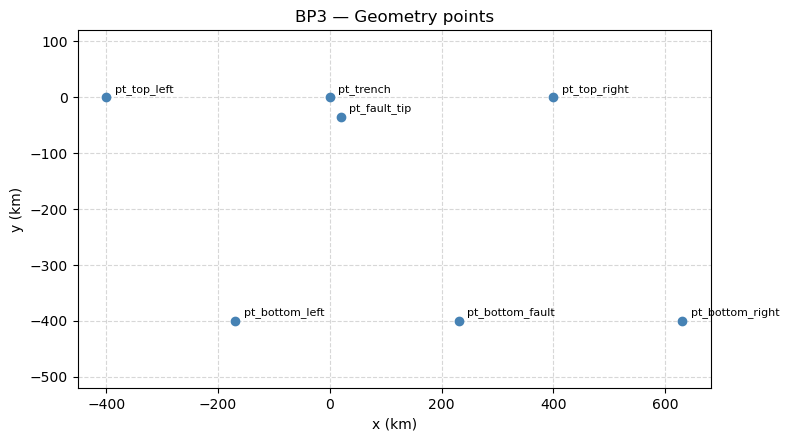

In [21]:
import matplotlib.pyplot as plt

# gmsh.model.geo.addPoint returns an integer tag
# we retrieve coordinates directly from the gmsh model
point_tags = {
    'pt_top_left':     pt_top_left,
    'pt_top_right':    pt_top_right,
    'pt_bottom_right': pt_bottom_right,
    'pt_bottom_left':  pt_bottom_left,
    'pt_bottom_fault': pt_bottom_fault,
    'pt_trench':       pt_trench,
    'pt_fault_tip':    pt_fault_tip,
}

fig, ax = plt.subplots(figsize=(8, 6))
for name, tag in point_tags.items():
    x, y, _ = gmsh.model.getValue(0, tag, [])  # get (x, y, z) for a point entity
    ax.plot(x, y, 'o', color='steelblue')
    ax.annotate(name, (x, y), textcoords='offset points', xytext=(6, 4), fontsize=8)

ax.set_xlabel('x (km)')
ax.set_ylabel('y (km)')
ax.set_title('BP3 — Geometry points')
ax.set_aspect('equal')
ax.set_ylim(-d*1.3, d*0.3)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Lines

Now we connect the points into lines.

| Name | From | To | Description |
|------|------|----|-------------|
| `l_top_left`                  | `pt_top_left`     | `pt_trench`       | Top free surface, left of the trench |
| `l_top_right`                 | `pt_trench`       | `pt_top_right`    | Top free surface, right of the trench |
| `l_right`                     | `pt_top_right`    | `pt_bottom_right` | Right side boundary |
| `l_bottom_right`              | `pt_bottom_right` | `pt_bottom_fault` | Bottom boundary on the upper-plate side |
| `l_bottom_left`               | `pt_bottom_fault` | `pt_bottom_left`  | Bottom boundary on the downgoing-plate side |
| `l_left`                      | `pt_bottom_left`  | `pt_top_left`     | Left side boundary |
| `rsf_fault`                   | `pt_trench`       | `pt_fault_tip`    | Rate-and-state friction segment |
| `dislocation_creeping_fault`  | `pt_fault_tip`    | `pt_bottom_fault` | Deeper creeping/dislocation continuation |

The RSF and creeping segments lie on the same dipping interface, but they receive different physical tags later. That distinction is important because Tandem treats the shallow RSF fault and the deeper prescribed/creeping part differently.

In [22]:
# Outer boundary
l_top_left     = gmsh.model.geo.addLine(pt_top_left,     pt_trench)
l_top_right    = gmsh.model.geo.addLine(pt_trench,       pt_top_right)
l_right        = gmsh.model.geo.addLine(pt_top_right,    pt_bottom_right)
l_bottom_right = gmsh.model.geo.addLine(pt_bottom_right, pt_bottom_fault)
l_bottom_left  = gmsh.model.geo.addLine(pt_bottom_fault, pt_bottom_left)
l_left         = gmsh.model.geo.addLine(pt_bottom_left,  pt_top_left)

# Fault
rsf_fault                  = gmsh.model.geo.addLine(pt_trench,    pt_fault_tip)
dislocation_creeping_fault = gmsh.model.geo.addLine(pt_fault_tip, pt_bottom_fault)

gmsh.model.geo.synchronize()  # push all lines to the gmsh model


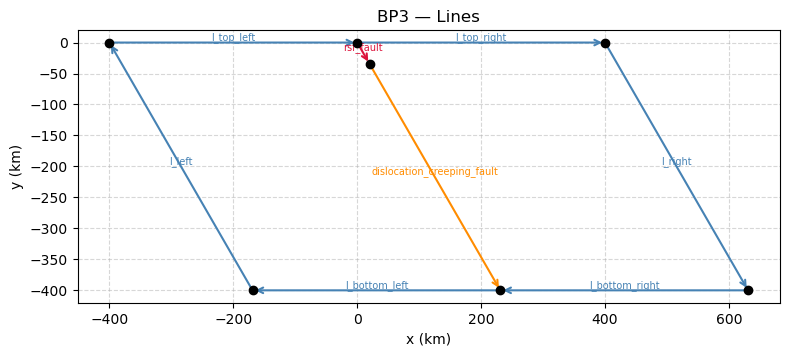

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))

# Lines defined as (line_tag, label, color)
lines = [
    (l_top_left,                 'l_top_left',                'steelblue'),
    (l_top_right,                'l_top_right',               'steelblue'),
    (l_right,                    'l_right',                   'steelblue'),
    (l_bottom_right,             'l_bottom_right',            'steelblue'),
    (l_bottom_left,              'l_bottom_left',             'steelblue'),
    (l_left,                     'l_left',                    'steelblue'),
    (rsf_fault,                  'rsf_fault',                 'crimson'),
    (dislocation_creeping_fault, 'dislocation_creeping_fault','darkorange'),
]

for tag, label, color in lines:
    # evaluate the line at t=0 (start) and t=1 (end)
    x0, y0, _ = gmsh.model.getValue(1, tag, [0])
    x1, y1, _ = gmsh.model.getValue(1, tag, [1])
    dx, dy = x1 - x0, y1 - y0
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
    ax.text(x0 + dx/2, y0 + dy/2, label, fontsize=7, color=color,
            ha='center', va='bottom')

# Plot points on top
for name, tag in point_tags.items():
    x, y, _ = gmsh.model.getValue(0, tag, [])
    ax.plot(x, y, 'o', color='black', zorder=5)
    # ax.annotate(name, (x, y), textcoords='offset points', xytext=(6, 4), fontsize=7)

ax.set_xlabel('x (km)')
ax.set_ylabel('y (km)')
ax.set_title('BP3 — Lines')
ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### The Gmsh GUI

If you were running this as a `.geo` script ( or locally and use `gmsh.fltk.run()` )
you would see something like this in the Gmsh GUI:


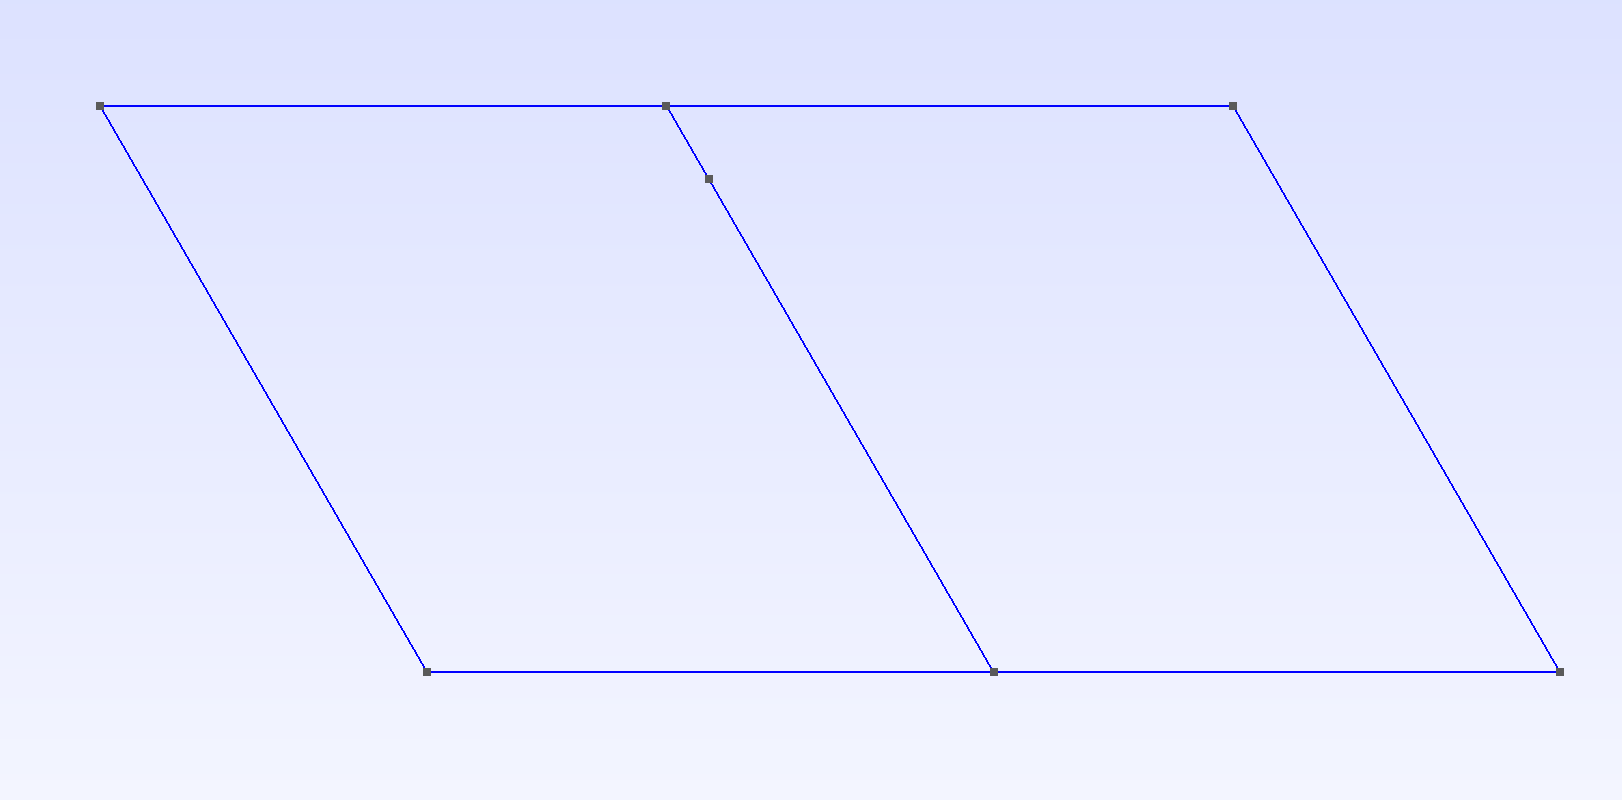

In [24]:
from IPython.display import Image, display
display(Image('gmsh_sc.png'))

# If you were running locally, you could open the Gmsh GUI with:
# gmsh.fltk.run()
# This won't work here because we are on a remote server with no display.

## Curve Loops & Surfaces

Now we use these lines to define surfaces.

We do it by **curve loop** which is an ordered list of lines that closes on itself. Gmsh uses curve loops to define 2D plane surfaces.

Here the fault divides the domain into two surfaces:

- `downgoing_plate`, on the left/below side of the interface.
- `upper_plate`, on the right/above side of the interface.

A negative line tag means that the line is traversed in the opposite direction. This is only about loop orientation; it does not create a new line.

| Name | Lines | Surface |
|------|-------|---------|
| `loop_downgoing_plate` | `rsf_fault, dislocation_creeping_fault, l_bottom_left, l_left, l_top_left` | `downgoing_plate` |
| `loop_upper_plate`     | `rsf_fault, dislocation_creeping_fault, -l_bottom_right, -l_right, -l_top_right` | `upper_plate` |

Both loops include the fault curves. This makes the fault an internal interface shared by the two plate surfaces, rather than just a line drawn inside one continuous surface.

In [25]:
# Curve loops — each loop must be closed and consistently oriented
# Negative line tag means the line is traversed in reverse
loop_downgoing_plate = gmsh.model.geo.addCurveLoop([
     rsf_fault,
     dislocation_creeping_fault,
     l_bottom_left,
     l_left,
     l_top_left
])

loop_upper_plate = gmsh.model.geo.addCurveLoop([
     rsf_fault,
     dislocation_creeping_fault,
    -l_bottom_right,
    -l_right,
    -l_top_right
])

# Plane surfaces from the loops
downgoing_plate = gmsh.model.geo.addPlaneSurface([loop_downgoing_plate])
upper_plate     = gmsh.model.geo.addPlaneSurface([loop_upper_plate])

gmsh.model.geo.synchronize()  # push surfaces to the gmsh model


## Physical Groups

Now we assign physical groups to the curves and surfaces so Tandem can use these to decide which boundary condition or friction law to apply to each part of the mesh.

| Tag | Dimension | Lines/Surfaces | Description |
|-----|-----------|---------------|-------------|
| `RSF_FAULT_TAG = 3`   | Curve | `rsf_fault` | Rate-and-state friction fault |
| `ZERO_STRESS_TAG = 1` | Curve | `l_top_left, l_top_right, l_bottom_right, l_bottom_left` | Zero-stress/free boundary condition |
| `DIRICHLET_TAG = 5`   | Curve | `l_right, l_left, dislocation_creeping_fault` | Prescribed displacement/Dirichlet-type boundary condition |
| auto-assigned         | Surface | `downgoing_plate` | Downgoing plate domain |
| auto-assigned         | Surface | `upper_plate` | Upper plate domain |

The important point is that the **numeric curve tags must match what Tandem expects**, here `1`, `3`, and `5`.

Surface tags are more flexible, but if you reference them in the Tandem Lua file, any changes here must also be updated there.

In [26]:
# Boundary condition tags — must match Tandem's expected values
RSF_FAULT_TAG   = 3   # Rate-and-state friction fault elements
ZERO_STRESS_TAG = 1   # Zero stress boundary
DIRICHLET_TAG   = 5   # Dirichlet BC (internal boundaries treated as dislocations)

# addPhysicalGroup(dim, tags, tag)
#   dim=1 → curve (1D boundary line)
#   dim=2 → surface (2D domain)


# Curves (dim=1)
gmsh.model.addPhysicalGroup(1, [rsf_fault], tag=RSF_FAULT_TAG)
gmsh.model.addPhysicalGroup(1, [l_top_left, l_top_right, l_bottom_right, l_bottom_left], tag=ZERO_STRESS_TAG)
gmsh.model.addPhysicalGroup(1, [l_right, l_left, dislocation_creeping_fault], tag=DIRICHLET_TAG)

# Surfaces (dim=2) — tags auto-assigned, stored for reference
downgoing_plate_tag = gmsh.model.addPhysicalGroup(2, [downgoing_plate])
upper_plate_tag     = gmsh.model.addPhysicalGroup(2, [upper_plate])

print(f'downgoing_plate tag: {downgoing_plate_tag}')
print(f'upper_plate tag:     {upper_plate_tag}')


downgoing_plate tag: 6
upper_plate tag:     7


## Mesh Size Fields

Now we define how the mesh size is defined across the domain. We want fine elements near the fault and trench , and coarser elements far away. Gmsh size fields let us prescribe this smoothly without making the whole domain fine.

Use use four fields:

**Field 1 — Distance from RSF fault**  
Computes the distance from every point in the domain to the `rsf_fault` curve. This distance is then used by the next field.

**Field 2 — Fault refinement**  
The desired element size is `Lf` directly on the RSF fault, then grows linearly with distance:

```text
Lf + fault_growth_rate * distance_from_fault
```

**Field 3 — Trench refinement**  
The desired element size is `Ls` at the trench `(0, 0)`, then grows radially outward:

```text
Ls + trench_growth_rate * sqrt(x² + y²)
```

**Field 4 — Background field**  
Takes the minimum of the fault-refinement and trench-refinement fields at every point. This means that a point is refined if it is close to either the RSF fault or the trench.

The growth rates have units of `km/km`. For example, with `fault_growth_rate = 0.1`, moving 10 km away from the fault increases the target element size by about 1 km. Smaller growth rates produce a wider refined zone; larger growth rates allow the mesh to coarsen more quickly.

In [27]:
fault_growth_rate  = 0.1   # linear growth rate of mesh size away from the fault (km/km)
trench_growth_rate = 0.1   # linear growth rate of mesh size away from the trench (km/km)

# Field 1: compute distance from the RSF fault curve
field_dist = gmsh.model.mesh.field.add('Distance')
gmsh.model.mesh.field.setNumbers(field_dist, 'CurvesList', [rsf_fault])
gmsh.model.mesh.field.setNumber(field_dist, 'Sampling', 1000)  # number of points sampled along the curve

# Field 2: Lf at the fault, linearly increasing with distance from it
field_fault = gmsh.model.mesh.field.add('MathEval')
gmsh.model.mesh.field.setString(field_fault, 'F',
    f'{Lf} + {fault_growth_rate} * F{field_dist}')

# Field 3: Ls at the trench, growing radially outward
field_trench = gmsh.model.mesh.field.add('MathEval')
gmsh.model.mesh.field.setString(field_trench, 'F',
    f'{Ls} + {trench_growth_rate} * Sqrt(x^2 + y^2)')

# Field 4: take the minimum of both fields everywhere
field_min = gmsh.model.mesh.field.add('Min')
gmsh.model.mesh.field.setNumbers(field_min, 'FieldsList', [field_fault, field_trench])

# Set as the global background field
gmsh.model.mesh.field.setAsBackgroundMesh(field_min)


## Generate & Export Mesh

The final step is to generate a 2D mesh and write it to disk.


In [28]:
gmsh.option.setNumber('Mesh.MshFileVersion', 2.2)  # ensure output mesh is in .msh format version 2.2 for compatibility with Tandem

gmsh.model.mesh.generate(2)          # generate 2D mesh
gmsh.write('bp3.msh')                # write mesh to file

gmsh.finalize()                      # close the gmsh API


Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 20%] Meshing curve 2 (Line)
Info    : [ 30%] Meshing curve 3 (Line)
Info    : [ 40%] Meshing curve 4 (Line)
Info    : [ 60%] Meshing curve 5 (Line)
Info    : [ 70%] Meshing curve 6 (Line)
Info    : [ 80%] Meshing curve 7 (Line)
Info    : [ 90%] Meshing curve 8 (Line)
Info    : Done meshing 1D (Wall 0.128587s, CPU 0.126362s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : [ 60%] Meshing surface 2 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.248595s, CPU 0.177619s)
Info    : 6739 nodes 13736 elements
Info    : Writing 'bp3.msh'...
Info    : Done writing 'bp3.msh'


## Verify mesh with check-bc

Run Tandem's `check-bc` tool on the mesh to confirm all boundary condition tags
are correctly assigned. The output is a VTU file you can open in ParaView.

In [ ]:
import subprocess
import shutil

check_bc = shutil.which('check-bc')
if check_bc is None:
    raise RuntimeError("check-bc not found in PATH")

result = subprocess.run(
    [check_bc, '2', 'bp3.msh', 'bp3_bc'],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)
else:
    print("check-bc passed - open bp3_bc.vtu in ParaView to inspect BCs")

# Try on Your Own

> ⚠️ Every time you change the mesh and run a new Tandem simulation you need to recompute the Green's functions , they depend on the mesh topology.


### 1. Try and change the mesh size parameters (Lf, Ls and h) and see how it affects the mesh.
The best approach would be to generate a function that gets Lf,Ls and h and generate a bp3 mesh using these values

### 2 . Mesh resolution and the nucleation length

The nucleation length $L$ is the critical length scale over which an earthquake nucleates. One commonly used formulation (Rubin & Ampuero, 2005), valid for $0.5 < a/b < 1$, is:

$$L = \frac{\pi \mu' b D_c}{2 (b-a)^2 \sigma_n}$$

where:
- $\mu' = \mu / (1 - \nu)$ — plane-strain shear modulus ($\mu$: shear modulus, $\nu$: Poisson's ratio)
- $D_c$ — characteristic slip distance
- $\sigma_n$ — effective normal stress


For a well-resolved simulation, the effective element size $h$ should satisfy $h \ll L$. As a a role of thumb in Tandem, $h \approx L_f / p$ where $p$ is the polynomial degree.

Compute $L$ for your BP3 parameters, compare it to $h$. If you have time  try changing `Lf`. Keep in mind: a larger `Lf` runs faster but may not resolve L.

In [ ]:
def get_L(mu, b, Dc, poisson, b_a, normal_stress):
    """Rubin & Ampuero (2005) nucleation length for 0.5 < a/b < 1 (plane strain)."""
    mu_prime = mu / (1 - poisson)   # plane-strain shear modulus
    return (np.pi * mu_prime * b * Dc) / (2 * (b_a)**2 * normal_stress)

# Fill in your BP3 parameters
mu            = ...   # Pa — shear modulus
poisson       = ...   # Poisson's ratio
b             = ...   # rate-state parameter b
a             = ...   # rate-state parameter a
Dc            = ...   # m — characteristic slip distance
normal_stress = ...   # Pa — effective normal stress

b_a   = b - a
L     = get_L(mu, b, Dc, poisson, b_a, normal_stress)

# Effective element size: h ≈ Lf / p
p     = ...   # polynomial degree used in Tandem
h_eff = (Lf * 1e3) / p   # convert Lf from km to m, then divide by p

print(f'Nucleation length  L     = {L:.1f} m  ({L/1e3:.3f} km)')
print(f'Effective element  h     = {h_eff:.1f} m  (Lf={Lf} km, p={p})')
print(f'Ratio              h/L   = {h_eff/L:.3f}  (should be << 1)')

 ### 3. Ratio of $L$ to $W$

Another important length scale is the ratio $L / W$, where $W$ is the width of the seismogenic zone , the along-dip extent of the velocity-weakening region.

Estimate $W$ from your BP3 setup. What is the ratio $L / W$ you are using? 

### 4. Different material properties per plate
Tandem passes the physical surface tag into the material functions, so you can assign
different elastic properties to each plate. On the Lua side, try something like this (change as you wish):

```lua
function BP3:mu(x, y, tag)
    if tag == downgoing_plate_tag then -- change downgoing_plate_tag with the tag used here 
        amp = 0.5
    elseif tag == upper_plate_tag then -- change upper_plate_tag with the tag used here 
        amp = 1.0
    end
    return self.cs^2 * self.rho0 * amp
end

function BP3:lam(x, y, tag)
    return 2 * self.nu * self:mu(x, y, tag) / (1 - 2 * self.nu)
end
```


### 5. Wedge-shaped upper plate
Modify the domain so the upper plate has a **wedge shape** with a sloping top surface at **20°**.
This means `pt_top_right` is no longer at `y = 0` — it should be elevated according to the 20° slope.
You will need to:
- Compute the new position of `pt_top_right` using `x * tan(20°)`
- Update `l_top_right` to connect `pt_trench` to the new `pt_top_right`
- Check that the curve loops still close correctly

### 6. Cascadia Topography from GEBCO

Try replacing the flat top surface with a real topographic profile from the Cascadia
subduction zone. We load a pre-computed smoothed topographic profile of the Cascadia subduction zone,
averaged over the latitude band **42°–46°N**, projected to km using UTM. See what it looks like below:

### Load and plot the profile

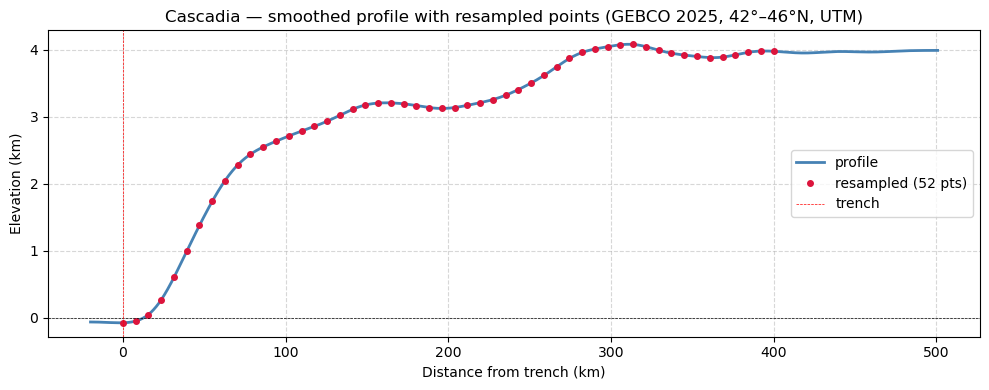

In [5]:
from scipy.interpolate import interp1d
import numpy as np
import matplotlib.pyplot as plt
data    = np.load('cascadia_profile.npz')
x_km    = data['x_km']
elev_km = data['elev_km']

# Resample to n_topo_pts points between x=0 and x=w
n_topo_pts = 50
f_interp   = interp1d(x_km, elev_km, kind='linear', fill_value='extrapolate')
xs_topo    = np.linspace(0, w, n_topo_pts + 2)
ys_topo    = f_interp(xs_topo)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_km, elev_km, color='steelblue', linewidth=2.0, label='profile')
ax.plot(xs_topo, ys_topo, 'o', color='crimson', markersize=4, label=f'resampled ({n_topo_pts+2} pts)')
ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
ax.axvline(0, color='r', linewidth=0.5, linestyle='--', label='trench')
ax.set_xlabel('Distance from trench (km)')
ax.set_ylabel('Elevation (km)')
ax.set_title('Cascadia — smoothed profile with resampled points (GEBCO 2025, 42°–46°N, UTM)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Use the profile as the free surface

Now use the red dots provided above as gmsh points to define a spline along the top surface.
Replace `l_top_right` with a spline through these points.

First add the intermediate points , note the finer mesh size `h/10` to resolve the topography:

```python
topo_pts = [
    gmsh.model.geo.addPoint(float(x), float(y), 0, h/10)
    for x, y in zip(xs_topo[1:-1], ys_topo[1:-1])
]
```

Then connect them with a spline instead of a straight line:

```python
l_top_right_topo = gmsh.model.geo.addSpline(
    [pt_trench] + topo_pts + [pt_top_right]
)
```

Replace `l_top_right` with `l_top_right_topo` in the curve loop and physical groups,
then re-run the mesh generation.